In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [36]:
df = pd.read_csv('train.csv')
df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [37]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


,0
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919


In [38]:
test = pd.read_csv('test.csv')
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [39]:
df['product_category'] = df['product_category'].str.lower()
test['product_category'] = test['product_category'].str.lower()

In [40]:
print(df['product_category'].unique())

['frozen foods' 'health and hygiene' 'canned' 'soft drinks' 'meat'
 'snack foods' 'baking goods' 'household' 'dairy' 'fruits and vegetables'
 'breakfast' 'breads' 'seafood' 'others' 'hard drinks' 'starchy foods']


In [41]:
print(test['product_category'].unique())

['household' 'health and hygiene' 'fruits and vegetables' 'frozen foods'
 'seafood' 'baking goods' 'starchy foods' 'snack foods' 'breads'
 'soft drinks' 'canned' 'meat' 'dairy' 'others' 'hard drinks' 'breakfast']


In [42]:
df['store_size'] = df['store_size'].fillna('Unknown')
test['store_size'] = test['store_size'].fillna('Unknown')

In [43]:
print(df['store_size'].value_counts())

store_size
Medium     2218
Small      1933
Unknown    1919
Large       748
Name: count, dtype: int64


In [44]:
df['product_weight_kg'] = df['product_weight_kg'].fillna(df.groupby('product_category')['product_weight_kg'].transform('median'))
test['product_weight_kg'] = test['product_weight_kg'].fillna(test.groupby('product_category')['product_weight_kg'].transform('median'))

In [45]:
df.isnull().sum()
test.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0


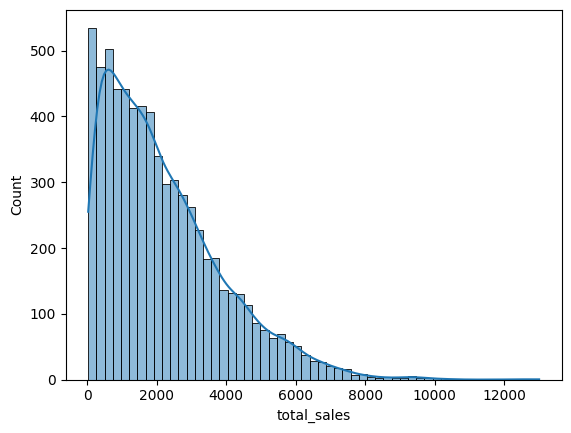

In [46]:
sns.histplot(df['total_sales'], kde=True)
plt.show()

In [47]:
df['log_total_sales'] = np.log1p(df['total_sales'])

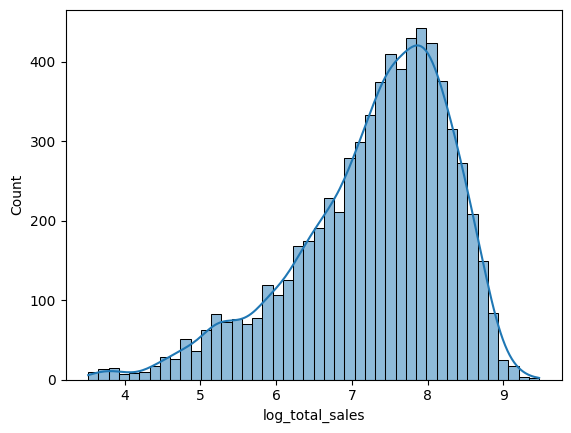

In [48]:
sns.histplot(df['log_total_sales'], kde=True)
plt.show()

In [49]:
# Combine train and test temporarily so encoding is consistent across both
df['is_train'] = 1
test['is_train'] = 0
test['total_sales'] = np.nan  # placeholder, test has no target
test['log_total_sales'] = np.nan

combined = pd.concat([df, test], sort=False)

# One-hot encode categorical columns
categorical_cols = ['fat_content', 'product_category', 'store_size', 'store_location_tier', 'store_format']
combined = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

# Split back into train/test
df_encoded = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test_encoded = combined[combined['is_train'] == 0].drop(columns=['is_train', 'total_sales', 'log_total_sales'])

In [50]:
feature_cols = [c for c in df_encoded.columns if c not in ['id', 'product_code', 'store_code', 'total_sales', 'log_total_sales']]

X = df_encoded[feature_cols]
y = df_encoded['log_total_sales']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_preds)))
print('Validation RMSE:', rmse)

Validation RMSE: 1188.6277790650247


In [51]:
test_preds_log = model.predict(test_encoded[feature_cols])
test_preds = np.expm1(test_preds_log)  # reverse the log1p transform

submission = pd.DataFrame({
    'id': test_encoded['id'],
    'total_sales': test_preds
})
submission.to_csv('submission.csv', index=False)

In [52]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [53]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_val_preds = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(xgb_val_preds)))
print('XGBoost Validation RMSE:', xgb_rmse)

XGBoost Validation RMSE: 1151.3658984287329


In [54]:
xgb_test_preds_log = xgb_model.predict(test_encoded[feature_cols])
xgb_test_preds = np.expm1(xgb_test_preds_log)

submission = pd.DataFrame({
    'id': test_encoded['id'],
    'total_sales': xgb_test_preds
})
submission.to_csv('submission.csv', index=False)

In [55]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmses = []
oof_preds = np.zeros(len(X))  # out-of-fold predictions, one per training row

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    fold_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
    fold_model.fit(X_tr, y_tr)

    fold_preds = fold_model.predict(X_vl)
    oof_preds[val_idx] = fold_preds

    fold_rmse = np.sqrt(mean_squared_error(np.expm1(y_vl), np.expm1(fold_preds)))
    fold_rmses.append(fold_rmse)
    print(f'Fold {fold+1} RMSE: {fold_rmse:.2f}')

overall_rmse = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(oof_preds)))
print(f'\nMean fold RMSE: {np.mean(fold_rmses):.2f}')
print(f'Overall OOF RMSE: {overall_rmse:.2f}')

Fold 1 RMSE: 1151.20
Fold 2 RMSE: 1090.21
Fold 3 RMSE: 1123.92
Fold 4 RMSE: 1163.32
Fold 5 RMSE: 1133.37

Mean fold RMSE: 1132.40
Overall OOF RMSE: 1132.68


In [56]:
final_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
final_model.fit(X, y)

final_test_preds_log = final_model.predict(test_encoded[feature_cols])
final_test_preds = np.expm1(final_test_preds_log)

submission = pd.DataFrame({
    'id': test_encoded['id'],
    'total_sales': final_test_preds
})
submission.to_csv('submission.csv', index=False)

In [57]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)

print('Best params:', search.best_params_)
print('Best CV RMSE (log-space):', -search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV RMSE (log-space): 0.523476569403072


In [58]:
tuned_model = XGBRegressor(
    subsample=0.9,
    n_estimators=400,
    max_depth=4,
    learning_rate=0.01,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

tuned_model.fit(X, y)

# Quick 5-fold CV check with the tuned params, for a fair comparison to your earlier 1132.68
kf = KFold(n_splits=5, shuffle=True, random_state=42)
tuned_oof = np.zeros(len(X))

for train_idx, val_idx in kf.split(X):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    m = XGBRegressor(subsample=0.9, n_estimators=400, max_depth=4, learning_rate=0.01, colsample_bytree=1.0, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    tuned_oof[val_idx] = m.predict(X_vl)

tuned_rmse = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(tuned_oof)))
print('Tuned model OOF RMSE:', tuned_rmse)
print('Previous (untuned) OOF RMSE: 1132.68')

Tuned model OOF RMSE: 1123.6301780617343
Previous (untuned) OOF RMSE: 1132.68


In [59]:
tuned_test_preds_log = tuned_model.predict(test_encoded[feature_cols])
tuned_test_preds = np.expm1(tuned_test_preds_log)

submission = pd.DataFrame({
    'id': test_encoded['id'],
    'total_sales': tuned_test_preds
})
submission.to_csv('submission.csv', index=False)